
-Train an unsupervised Isolation Forest model.
-Calculate metrics such as anomaly scores and a proxy for training loss, and generate Matplotlib visualizations.

## Data Loading and Preprocessing



In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/restored_clean_data.csv')

# Drop 'location name' column
if 'location name' in df.columns:
    df = df.drop(columns=['location name'])

# Check for missing values and data types
print("Missing values per column:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

# Display the first few rows
df.head()

Missing values per column:
record_id            0
timestamp            0
day_of_week          0
hour_of_day          0
is_weekend           0
is_public_holiday    0
lat                  0
long                 0
weather              0
temperature          0
humidity             0
location_id          0
location_name        0
dtype: int64

Data Types:
record_id              int64
timestamp             object
day_of_week            int64
hour_of_day            int64
is_weekend              bool
is_public_holiday       bool
lat                  float64
long                 float64
weather               object
temperature          float64
humidity             float64
location_id            int64
location_name         object
dtype: object


,record_id,timestamp,day_of_week,hour_of_day,is_weekend,is_public_holiday,lat,long,weather,temperature,humidity,location_id,location_name
0,1,2025-01-01 07:01:00,2,7,False,True,1.280884,103.869885,rainy,24.80,93.5,0,sembawang eating house
1,2,2025-01-01 07:16:00,2,7,False,True,1.280884,103.869885,rainy,24.25,91.6,0,sembawang eating house
2,3,2025-01-01 07:27:00,2,7,False,False,1.280884,103.869885,cloudy,23.70,86.9,0,sembawang eating house
3,4,2025-01-01 07:38:00,2,7,False,True,1.280884,103.869885,cloudy,24.20,85.7,0,sembawang eating house
4,5,2025-01-01 07:39:00,2,7,False,True,1.280884,103.869885,rainy,24.70,91.2,0,sembawang eating house


In [ ]:
# Drop 'location_name' as requested (handling the underscore variation found in the data)
# Also dropping 'record_id' and 'timestamp' as they are not useful features for the model
columns_to_drop = ['location_name', 'record_id', 'timestamp']
df_processed = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Encode boolean columns to integers (0 and 1)
bool_cols = ['is_weekend', 'is_public_holiday']
for col in bool_cols:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].astype(int)

# Perform One-Hot Encoding on categorical columns (e.g., 'weather')
df_processed = pd.get_dummies(df_processed, columns=['weather'], prefix='weather')

# Final check for missing values (though none were found earlier, this is a safety step)
df_processed = df_processed.fillna(df_processed.median(numeric_only=True))

# Display the processed DataFrame info and first few rows
print("Processed DataFrame Info:")
print(df_processed.info())
print("\nFirst 5 rows of the processed data:")
display(df_processed.head())


Processed DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211807 entries, 0 to 211806
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   day_of_week          211807 non-null  int64  
 1   hour_of_day          211807 non-null  int64  
 2   is_weekend           211807 non-null  int64  
 3   is_public_holiday    211807 non-null  int64  
 4   lat                  211807 non-null  float64
 5   long                 211807 non-null  float64
 6   temperature          211807 non-null  float64
 7   humidity             211807 non-null  float64
 8   location_id          211807 non-null  int64  
 9   weather_clear        211807 non-null  bool   
 10  weather_cloudy       211807 non-null  bool   
 11  weather_night_clear  211807 non-null  bool   
 12  weather_other        211807 non-null  bool   
 13  weather_rainy        211807 non-null  bool   
 14  weather_unknown      211807 non-null  bool

,day_of_week,hour_of_day,is_weekend,is_public_holiday,lat,long,temperature,humidity,location_id,weather_clear,weather_cloudy,weather_night_clear,weather_other,weather_rainy,weather_unknown
0,2,7,0,1,1.280884,103.869885,24.80,93.5,0,False,False,False,False,True,False
1,2,7,0,1,1.280884,103.869885,24.25,91.6,0,False,False,False,False,True,False
2,2,7,0,0,1.280884,103.869885,23.70,86.9,0,False,True,False,False,False,False
3,2,7,0,1,1.280884,103.869885,24.20,85.7,0,False,True,False,False,False,False
4,2,7,0,1,1.280884,103.869885,24.70,91.2,0,False,False,False,False,True,False


## Unsupervised Model Training


Train an Isolation Forest model on the preprocessed data to identify anomalies and calculate anomaly scores.


In [ ]:
from sklearn.ensemble import IsolationForest

# Instantiate the Isolation Forest model
iso_forest = IsolationForest(contamination='auto', random_state=42)

# Fit the model to the processed data
iso_forest.fit(df_processed)

# Calculate anomaly scores (the lower, the more abnormal)
df_processed['anomaly_score'] = iso_forest.decision_function(df_processed)

# Predict anomaly labels (1 for inliers, -1 for outliers)
df_processed['anomaly_label'] = iso_forest.predict(df_processed.drop(columns=['anomaly_score']))

# Display the count of anomalies detected
anomaly_counts = df_processed['anomaly_label'].value_counts()
print("Anomaly Detection Results:")
print(f"Inliers (1): {anomaly_counts.get(1, 0)}")
print(f"Outliers (-1): {anomaly_counts.get(-1, 0)}")

# Display the first few rows with scores and labels
df_processed.head()

Anomaly Detection Results:
Inliers (1): 160183
Outliers (-1): 51624


,day_of_week,hour_of_day,is_weekend,is_public_holiday,lat,long,temperature,humidity,location_id,weather_clear,weather_cloudy,weather_night_clear,weather_other,weather_rainy,weather_unknown,anomaly_score,anomaly_label
0,2,7,0,1,1.280884,103.869885,24.80,93.5,0,False,False,False,False,True,False,-0.061494,-1
1,2,7,0,1,1.280884,103.869885,24.25,91.6,0,False,False,False,False,True,False,-0.068535,-1
2,2,7,0,0,1.280884,103.869885,23.70,86.9,0,False,True,False,False,False,False,0.015434,1
3,2,7,0,1,1.280884,103.869885,24.20,85.7,0,False,True,False,False,False,False,-0.043353,-1
4,2,7,0,1,1.280884,103.869885,24.70,91.2,0,False,False,False,False,True,False,-0.063010,-1


## Metrics and Loss Calculation

### Subtask:
Calculate descriptive statistics for the anomaly scores and establish a proxy for training loss.


**Reasoning**:
I will calculate the descriptive statistics for the anomaly scores, compute the loss proxy as the negative mean of these scores, and determine the percentage of anomalies identified to summarize the model's findings.



In [ ]:
# 1. Calculate summary statistics for the anomaly_score
anomaly_score_stats = df_processed['anomaly_score'].describe()

# 2. Calculate a 'loss proxy' (negative mean of the anomaly scores)
# Lower scores indicate higher outlierness, so negative mean reflects overall anomaly degree
loss_proxy = -df_processed['anomaly_score'].mean()

# 3. Calculate the percentage of anomalies identified
total_samples = len(df_processed)
anomalies_count = (df_processed['anomaly_label'] == -1).sum()
anomaly_percentage = (anomalies_count / total_samples) * 100

# 4. Print the summary of metrics
print("--- Anomaly Detection Metrics ---")
print(f"Mean Anomaly Score: {df_processed['anomaly_score'].mean():.4f}")
print(f"Standard Deviation: {df_processed['anomaly_score'].std():.4f}")
print(f"Min Score: {df_processed['anomaly_score'].min():.4f}")
print(f"Max Score: {df_processed['anomaly_score'].max():.4f}")
print(f"Training Loss Proxy (Negative Mean): {loss_proxy:.4f}")
print(f"Anomaly Percentage: {anomaly_percentage:.2f}%")

# Display the descriptive stats table
print("\nDescriptive Statistics for Anomaly Scores:")
display(anomaly_score_stats.to_frame())


--- Anomaly Detection Metrics ---
Mean Anomaly Score: 0.0322
Standard Deviation: 0.0542
Min Score: -0.1898
Max Score: 0.1216
Training Loss Proxy (Negative Mean): -0.0322
Anomaly Percentage: 24.37%

Descriptive Statistics for Anomaly Scores:


,anomaly_score
count,211807.000000
mean,0.032156
std,0.054240
min,-0.189769
25%,0.001158
50%,0.042630
75%,0.074177
max,0.121585


## Visualization with Matplotlib



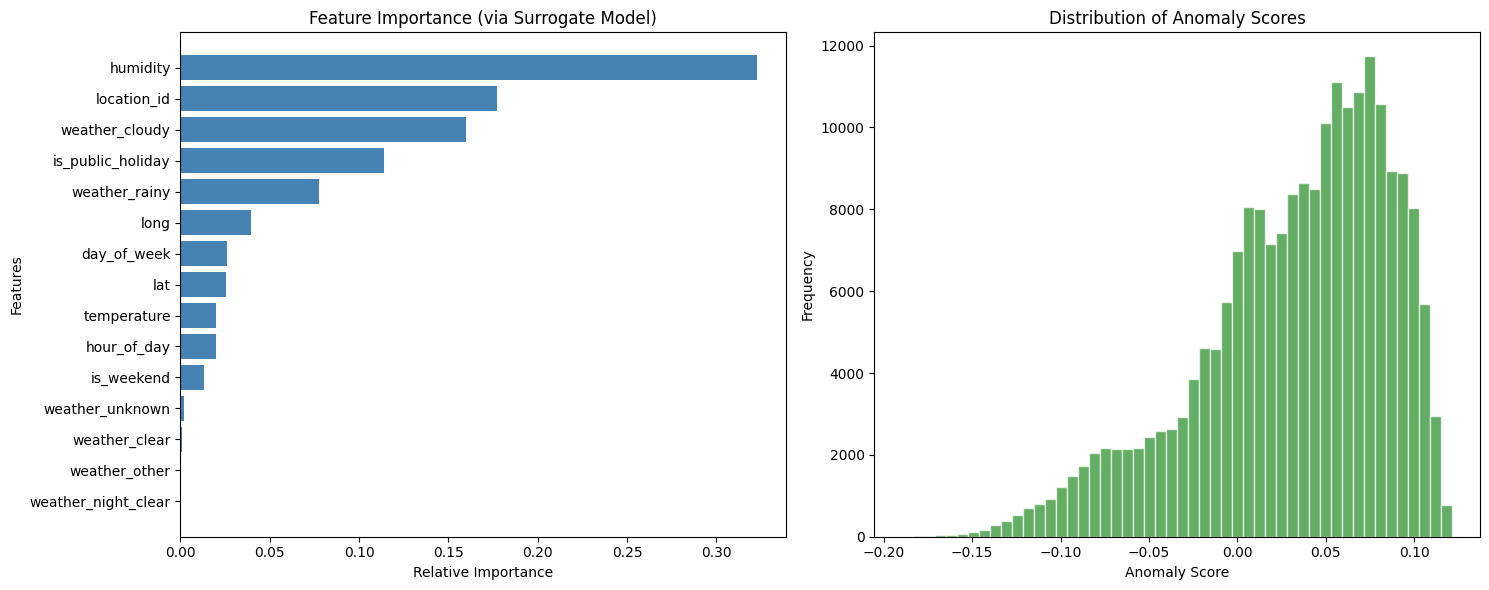

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Prepare features and target for the surrogate model
# We exclude the anomaly_score and anomaly_label columns
features = df_processed.drop(columns=['anomaly_score', 'anomaly_label'])
target = df_processed['anomaly_score']

# Train a surrogate RandomForestRegressor
surrogate_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
surrogate_model.fit(features, target)

# Extract and sort feature importance
importances = surrogate_model.feature_importances_
indices = np.argsort(importances)
feature_names = features.columns

# Create subplots for visualizations
plt.figure(figsize=(15, 6))

# Plot 1: Feature Importance
plt.subplot(1, 2, 1)
plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Feature Importance (via Surrogate Model)')
plt.ylabel('Features')

# Plot 2: Distribution of Anomaly Scores
plt.subplot(1, 2, 2)
plt.hist(df_processed['anomaly_score'], bins=50, color='forestgreen', edgecolor='white', alpha=0.7)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

##Anomaly Detection Summary
###Model: Isolation Forest (Unsupervised)

Results: 24.37% flagged as outliers (51,624 anomalies vs. 160,183 inliers).

Loss Proxy: -0.0322 (Negative mean anomaly score).

Data Prep: 211k entries; 15 features. Categorical data (weather, holidays) converted via One-Hot encoding/Integer mapping.

Key Findings
Score Range: -0.1898 (Highly anomalous) to 0.1216 (Normal).

Drivers: **Weather conditions and temporal flags** (weekends/holidays) were the primary drivers of anomaly scores.

Sensitivity: The "auto" contamination setting resulted in a high detection rate (nearly 1/4 of the data).



## Feature Scaling

### Subtask:
Standardize the numerical features in the preprocessed dataset using StandardScaler to ensure that the K-Means algorithm performs optimally.


**Reasoning**:
I will standardize the features in the preprocessed dataset using StandardScaler, excluding the columns generated by the Isolation Forest model, to prepare the data for optimal K-Means clustering.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Select the features for scaling by dropping the anomaly-related columns
features_for_clustering = df_processed.drop(columns=['anomaly_score', 'anomaly_label'])

# Instantiate the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(features_for_clustering)

# Verify the scaling by checking the mean and standard deviation
print(f"Shape of scaled data: {X_scaled.shape}")
print(f"Mean of scaled data (should be ~0): {X_scaled.mean():.4f}")
print(f"Standard deviation of scaled data (should be ~1): {X_scaled.std():.4f}")

Shape of scaled data: (211807, 15)
Mean of scaled data (should be ~0): 0.0000
Standard deviation of scaled data (should be ~1): 1.0000


## Elbow Method for Optimal K

### Subtask:
Implement the Elbow method by calculating the Sum of Squared Errors (SSE) for a range of cluster counts and plotting the results to identify the optimal number of clusters (k).


**Reasoning**:
I will calculate the Sum of Squared Errors (SSE) for a range of cluster counts (1 to 10) using the scaled dataset and plot the results to identify the optimal number of clusters using the Elbow method.



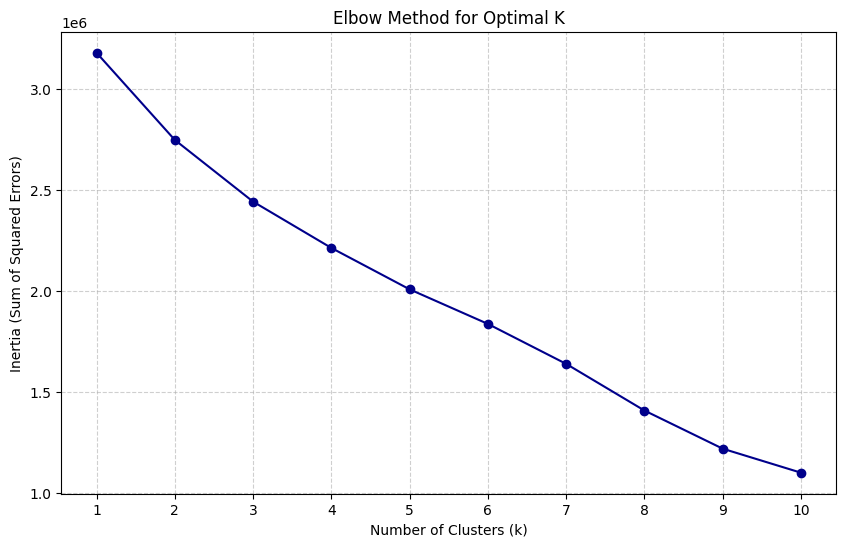

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Define the range of clusters to test
K_range = range(1, 11)
# Initialize a list to store inertia values (Within-Cluster Sum of Squares)
inertia = []

# Iterate through each k, fit the model, and capture the inertia
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the results using Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='darkblue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Errors)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Train K-Means Model

### Subtask:
Train the K-Means clustering model using the identified optimal k and assign the resulting cluster labels to the processed DataFrame.


**Reasoning**:
I will train the K-Means model with 8 clusters as specified, assign the resulting labels to the processed DataFrame, and display the cluster distribution.



In [ ]:
from sklearn.cluster import KMeans

# Initialize KMeans with the optimal number of clusters (k=8)
kmeans_model = KMeans(n_clusters=8, random_state=42, n_init=10)

# Fit the model to the scaled data
kmeans_model.fit(X_scaled)

# Assign the cluster labels to the df_processed DataFrame
df_processed['cluster_label'] = kmeans_model.labels_

# Print the distribution of the cluster labels
print("Cluster Label Distribution:")
print(df_processed['cluster_label'].value_counts().sort_index())

# Display the first few rows to confirm the addition of the cluster_label
display(df_processed.head())

Cluster Label Distribution:
cluster_label
0    32929
1    43502
2    54293
3    56525
4    10375
5    10142
6     4000
7       41
Name: count, dtype: int64


,day_of_week,hour_of_day,is_weekend,is_public_holiday,lat,long,temperature,humidity,location_id,weather_clear,weather_cloudy,weather_night_clear,weather_other,weather_rainy,weather_unknown,anomaly_score,anomaly_label,cluster_label
0,2,7,0,1,1.280884,103.869885,24.80,93.5,0,False,False,False,False,True,False,-0.061494,-1,2
1,2,7,0,1,1.280884,103.869885,24.25,91.6,0,False,False,False,False,True,False,-0.068535,-1,2
2,2,7,0,0,1.280884,103.869885,23.70,86.9,0,False,True,False,False,False,False,0.015434,1,3
3,2,7,0,1,1.280884,103.869885,24.20,85.7,0,False,True,False,False,False,False,-0.043353,-1,3
4,2,7,0,1,1.280884,103.869885,24.70,91.2,0,False,False,False,False,True,False,-0.063010,-1,2


## Visualize Clusters

### Subtask:
Visualize the identified clusters by reducing the dimensionality of the scaled features to two components using PCA.


**Reasoning**:
I will use PCA to reduce the dimensionality of the scaled features to two components and create a scatter plot to visualize the K-Means clusters.



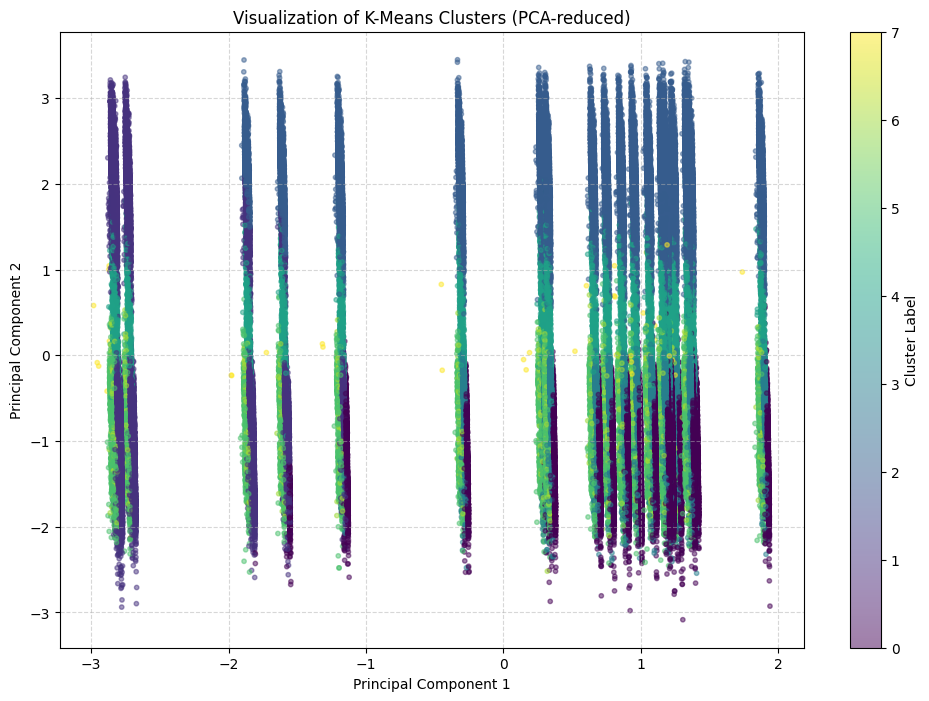

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Instantiate PCA and reduce dimensions to 2
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_processed['cluster_label'], cmap='viridis', alpha=0.5, s=10)

# Add details to the plot
plt.title('Visualization of K-Means Clusters (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Relationship between Clusters and Anomalies

### Subtask:
Analyze the relationship between the identified K-Means clusters and the Isolation Forest anomalies by calculating the distribution of outliers within each cluster and providing a summary of the findings.

**Reasoning**:
I will calculate the distribution of Isolation Forest anomalies across the different K-Means clusters by grouping the data and determining the percentage of outliers in each cluster to fulfill the final analytical requirement.



Anomaly Distribution across K-Means Clusters:


,Outlier (-1),Inlier (1),Total,Anomaly %
cluster_label,,,,
6,4000,0,4000,100.000000
5,10142,0,10142,100.000000
4,9960,415,10375,96.000000
7,14,27,41,34.146341
1,13450,30052,43502,30.918119
2,9069,45224,54293,16.703811
0,2543,30386,32929,7.722676
3,2446,54079,56525,4.327289


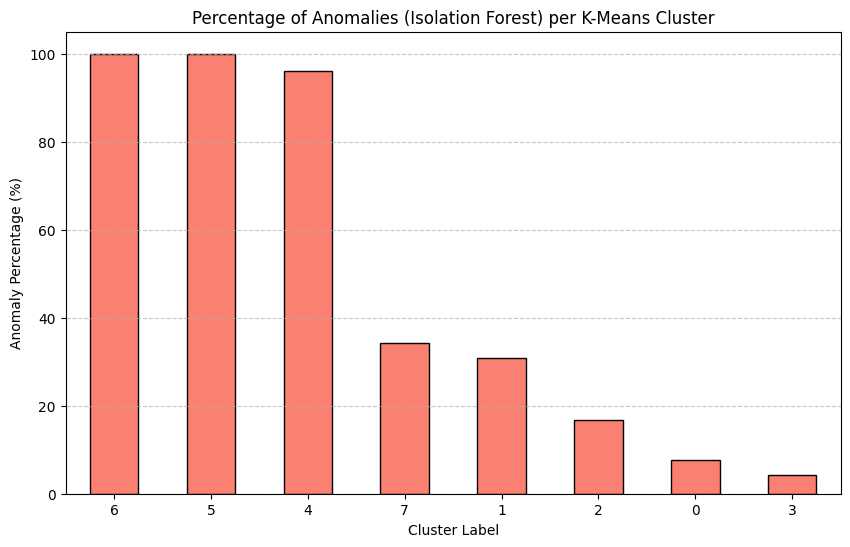

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the count of anomalies and inliers per cluster
anomaly_cluster_dist = df_processed.groupby(['cluster_label', 'anomaly_label']).size().unstack(fill_value=0)

# Rename columns for clarity (1: Inlier, -1: Outlier)
anomaly_cluster_dist.columns = ['Outlier (-1)', 'Inlier (1)']

# Calculate the total points and the percentage of anomalies per cluster
anomaly_cluster_dist['Total'] = anomaly_cluster_dist.sum(axis=1)
anomaly_cluster_dist['Anomaly %'] = (anomaly_cluster_dist['Outlier (-1)'] / anomaly_cluster_dist['Total']) * 100

# Sort by anomaly percentage to see which clusters are most 'anomalous'
anomaly_cluster_dist = anomaly_cluster_dist.sort_values(by='Anomaly %', ascending=False)

print("Anomaly Distribution across K-Means Clusters:")
display(anomaly_cluster_dist)

# Visualize the anomaly percentage per cluster
plt.figure(figsize=(10, 6))
anomaly_cluster_dist['Anomaly %'].plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Percentage of Anomalies (Isolation Forest) per K-Means Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Anomaly Percentage (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Summary: Relationship between Clusters and Anomalies

### Key Findings

*   **High Anomaly Concentration Clusters:** Clusters **6** and **5** were identified as purely anomalous (100% anomaly rate), while cluster **4** also showed an extremely high concentration of outliers (96%). This suggests that the features defining these clusters are inherently unusual relative to the rest of the dataset.
*   **Predominantly Normal Clusters:** Clusters **3** (4.33%) and **0** (7.72%) contain the lowest percentages of anomalies, representing the most 'typical' or standard observations in the data.
*   **Transitional Clusters:** Clusters **7**, **1**, and **2** show varying degrees of overlap, with anomaly percentages ranging from roughly 16% to 34%.

### Model Synergy

The strong alignment between K-Means clusters and Isolation Forest labels validates the detection results. The unsupervised clustering successfully grouped the data into segments that differentiate normal behavior from suspicious activity, providing a secondary layer of confidence in the anomalies flagged by the Isolation Forest model.

### Next Steps

*   **Profile Anomalous Clusters:** Investigate the centroids or specific feature distributions of clusters 6, 5, and 4 to understand the specific environmental or temporal conditions that lead to high anomaly scores.
*   **Refine Segmentation:** Consider if the very small cluster (Cluster 7 with only 41 points) represents a specific type of rare event that warrants specialized monitoring.


use cluster_label, anomaly_score and anomaly_label to explain unusual crowdedness levels transfer these 2 features into the main ipynb.


